# Foundations of NLP — Assignment Solution Notebook

This notebook solves the assignment **“Training and Evaluating a Small Transformer Language Model”** using **nanoGPT**.

It includes:

- the required **baseline run**
- **five controlled hyperparameter experiments** with one variable changed at a time
- automatic **log parsing**, **summary tables**, and **loss plots**
- **three 500-token samples** for every main experiment
- **Bonus A** with a custom dataset (**WikiText-2**)
- **Bonus B** with our own **Byte Pair Encoding (BPE)** tokenizer integrated into the nanoGPT data pipeline

We keep the notebook **Google Colab friendly**, **reproducible**, and **heavily commented**.


## 1. Setup and reproducibility

The next cell:

1. clones `nanoGPT` in Colab,

3. defines one **global random seed**,
4. creates folders for configs, logs, plots and samples.



In [ ]:
#import libraries

import os
import sys
import re
import json
import time
import math
import pickle
import shutil
import random
import textwrap
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [ ]:
# Install the exact package family requested in the assignment.
required_packages = [
    "torch",
    "numpy",
    "transformers",
    "datasets",
    "tiktoken",
    "wandb",
    "tqdm",
    "matplotlib",
    "pandas",
]

In [ ]:
# Path where the nanoGPT repository will live inside Colab.
REPO_DIR = Path("/content/nanoGPT")

In [ ]:
# Clone the repository
if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/karpathy/nanoGPT.git", str(REPO_DIR)],
        check=True,
    )

In [ ]:
# Install all required Python packages quietly (-q).
# We use sys.executable so pip installs into the currently active
# Python environment of the notebook runtime.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + required_packages,
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'torch', 'numpy', 'transformers', 'datasets', 'tiktoken', 'wandb', 'tqdm', 'matplotlib', 'pandas'], returncode=0)

In [ ]:
# --- Reproducibility --------------------------------------------------------
# We set one global seed and reuse it everywhere random behavior can occur.
# This helps us get repeatable results across notebook reruns.
#
# Important note:
# Exact reproducibility is easier on CPU than on GPU.
# Even with fixed seeds, tiny differences can still happen depending on
# hardware, library versions, and low-level CUDA behavior.
SEED = 1337

def set_global_seed(seed=SEED):
    """
    Set seeds for all major randomness sources used in this notebook.

    Why each line matters:
    - PYTHONHASHSEED: makes Python hashing deterministic
    - random.seed: Python's built-in random module
    - np.random.seed: NumPy randomness
    - torch.manual_seed: PyTorch CPU randomness
    - torch.cuda.manual_seed_all: PyTorch GPU randomness
    - cudnn.deterministic = True: prefers deterministic CUDA algorithms
    - cudnn.benchmark = False: avoids nondeterministic algorithm selection
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
# Apply the seed settings immediately so every later step starts from
# the same random state.
set_global_seed(SEED)

In [ ]:
# --- Runtime detection ------------------------------------------------------
# Detect whether a GPU is available.
# If CUDA is available, we use it; otherwise we fall back to CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# compile=False is more portable across Colab sessions and hardware.
# It may be slower than some optimized GPU setups, but it is usually more
# stable and reduces the chance of runtime-specific issues.
COMPILE = False

In [ ]:
# Change the current working directory to the nanoGPT repository so that
# relative paths used later in the notebook work correctly.
os.chdir(REPO_DIR)

In [ ]:
# Define commonly used folders for configs, logs, plots, samples, and
# report assets. Keeping outputs organized makes the notebook easier
# to debug and the final submission easier to assemble.
CONFIG_DIR = REPO_DIR / "config"
LOG_DIR = REPO_DIR / "logs"
PLOT_DIR = REPO_DIR / "plots"
SAMPLE_DIR = REPO_DIR / "samples"
REPORT_DIR = REPO_DIR / "report_assets"


In [ ]:
# Create output directories if they do not already exist.
# parents=True allows nested directory creation.
# exist_ok=True prevents errors if a folder is already there.
for directory in [LOG_DIR, PLOT_DIR, SAMPLE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
# Print the most important environment information so we can quickly check
# whether the notebook is running in the expected setup.
print(f"Working directory : {REPO_DIR}")
print(f"Device            : {DEVICE}")
print(f"Compile           : {COMPILE}")
print(f"Global seed       : {SEED}")

Working directory : /content/nanoGPT
Device            : cuda
Compile           : False
Global seed       : 1337


## 2. Prepare the Tiny Shakespeare character dataset

The assignment uses the built-in Tiny Shakespeare character dataset prepared by data/shakespeare_char/prepare.py.
This creates the binary files that nanoGPT expects for character-level training: train.bin and val.bin in the data directory.

In [ ]:
#subprocess.run(...) starts a separate process from Python.
#sys.executable means “use the current Python interpreter,” so in Colab it uses the same Python environment as the notebook.
#"data/shakespeare_char/prepare.py" is the nanoGPT script that downloads and preprocesses the Tiny Shakespeare dataset.
#cwd=REPO_DIR means the command is executed from inside the nanoGPT folder, so the relative path data/shakespeare_char/prepare.py can be found correctly.
#check=True means Python raises an error if the script fails.

subprocess.run(
    [sys.executable, "data/shakespeare_char/prepare.py"],
    cwd=REPO_DIR,
    check=True,

)
print("Character-level Shakespeare dataset prepared successfully.")

Character-level Shakespeare dataset prepared successfully.


## 3. Helper functions

We define helper functions to:

- write config files,
- train one experiment and save its log,
- record wall-clock time,
- generate samples with a fixed seed,
- parse nanoGPT logs back into curves and tables.

This keeps the main experiment cells short and makes the notebook easier to rerun.

In [ ]:
from typing import Dict, Any, List
from collections import Counter

In [ ]:
# The baseline configuration is defined once here and then reused for all
# experiments. Each later experiment only changes the values that should differ
# from the baseline, which helps us keep comparisons controlled and fair.
BASE_CONFIG: Dict[str, Any] = {
    "out_dir": "out-shakespeare-baseline",   # folder where checkpoints/logs are stored
    "eval_interval": 250,                    # evaluate on train/val split every 250 steps
    "eval_iters": 200,                       # number of batches used for each evaluation
    "log_interval": 10,                      # print training loss every 10 iterations
    "always_save_checkpoint": False,         # save checkpoint only when needed, not every eval
    "wandb_log": False,                      # disable Weights & Biases logging for simplicity
    "wandb_project": "nanoGPT-assignment",   # project name in case wandb is enabled later
    "wandb_run_name": "baseline",            # default run name
    "dataset": "shakespeare_char",           # use the prepared Tiny Shakespeare char dataset
    "gradient_accumulation_steps": 1,        # no gradient accumulation; one batch per update
    "batch_size": 64,                        # number of training examples per batch
    "block_size": 256,                       # context length: model sees at most 256 chars
    "n_layer": 6,                            # number of transformer blocks
    "n_head": 6,                             # number of attention heads
    "n_embd": 384,                           # embedding dimension / hidden size
    "dropout": 0.2,                          # dropout for regularization
    "learning_rate": 1e-3,                   # baseline learning rate
    "max_iters": 5000,                       # total number of training iterations
    "lr_decay_iters": 5000,                  # decay learning rate over the full training run
    "min_lr": 1e-4,                          # minimum learning rate after decay
    "beta2": 0.99,                           # AdamW beta2 parameter
    "warmup_iters": 100,                     # short warmup before full learning rate
    "weight_decay": 1e-1,                    # weight decay regularization
    "device": DEVICE,                        # cpu or cuda, detected earlier
    "compile": COMPILE,                      # whether to use PyTorch compile
    "seed_offset": 0,                        # fixed seed offset for reproducibility
}

In [ ]:
def config_to_text(config):
    """
    Convert a Python dictionary into the plain assignment-style config format
    expected by nanoGPT.

    nanoGPT config files are ordinary Python files with lines like:
        batch_size = 64
        learning_rate = 0.001

    We write every value explicitly so the experiment setup is fully reproducible.
    """
    header = [
        "# Auto-generated by the assignment notebook.",
        "# Every setting is written explicitly for reproducibility.",
        "",
    ]

    # Turn each key-value pair into a Python assignment line.
    body = [f"{key} = {repr(value)}" for key, value in config.items()]

    # Join header + body into one text block and end with a newline.
    return "\n".join(header + body) + "\n"

In [ ]:
def write_config_file(config_name, overrides):
    """
    Create one nanoGPT config file by starting from the baseline config and
    replacing only the settings given in 'overrides'.

    Example:
        write_config_file("train_lr_low.py", {"learning_rate": 1e-4})

    This keeps all non-varied hyperparameters fixed, which is exactly what the
    assignment asks for in controlled experiments.
    """
    config = BASE_CONFIG.copy()   # copy baseline so the original stays unchanged
    config.update(overrides)      # apply experiment-specific changes

    config_path = CONFIG_DIR / config_name
    config_path.write_text(config_to_text(config), encoding="utf-8")

    return config_path

In [ ]:
def run_and_log(command, log_path, cwd=REPO_DIR):
    """
    Run a command in a subprocess, print its output live in the notebook, and
    save the same output to a log file.

    Why this helper is useful:
    - We can see progress directly in the notebook.
    - We also keep a permanent log file for later parsing and plotting.
    - We measure wall-clock time for the assignment summary table.
    """
    print("Running command:")
    print(" ".join(command))
    print("-" * 80)

    # Start a timer so we can measure total runtime in minutes.
    start_time = time.perf_counter()

    with open(log_path, "w", encoding="utf-8") as log_file:
        process = subprocess.Popen(
            command,
            cwd=str(cwd),              # run inside nanoGPT repo
            stdout=subprocess.PIPE,    # capture stdout
            stderr=subprocess.STDOUT,  # merge stderr into stdout
            text=True,                 # decode output as text instead of bytes
            bufsize=1,                 # line-buffered output for live printing
        )

        # Stream output line by line:
        # - print it to the notebook
        # - write it into the log file
        for line in process.stdout:
            print(line, end="")
            log_file.write(line)

        return_code = process.wait()
    # Convert runtime into minutes for easier reporting.
    elapsed_minutes = (time.perf_counter() - start_time) / 60.0

    # If the command failed, raise an explicit error.
    if return_code != 0:
        raise RuntimeError(
            f"Command failed with exit code {return_code}. Check log file: {log_path}"
        )

    print("-" * 80)
    print(f"Finished successfully in {elapsed_minutes:.2f} minutes.")
    return elapsed_minutes


In [ ]:
def train_experiment(exp_name, config_path):
    """
    Train one experiment using a given nanoGPT config file.

    This function:
    1. runs train.py,
    2. stores the training log,
    3. stores the elapsed wall-clock time in a small JSON file,
    4. returns the runtime in minutes.
    """
    log_path = LOG_DIR / f"{exp_name}.log"

    elapsed_minutes = run_and_log(
        [sys.executable, "train.py", str(config_path.relative_to(REPO_DIR))],
        log_path=log_path,
        cwd=REPO_DIR,
    )

    # Save the runtime separately so we can load it later for the summary table
    # without reparsing notebook output.
    time_path = LOG_DIR / f"{exp_name}_time_minutes.json"
    time_path.write_text(
        json.dumps({"experiment": exp_name, "time_minutes": elapsed_minutes}, indent=2),
        encoding="utf-8",
    )

    return elapsed_minutes

In [ ]:
def sample_experiment(exp_name, out_dir, num_samples=3, max_new_tokens=500):
    """
    Generate text samples from a trained model checkpoint.

    We use the same seed again so sampling stays reproducible across reruns.
    The generated samples are written directly to a text file, which can later
    be used in the qualitative analysis appendix.
    """
    sample_path = SAMPLE_DIR / f"{exp_name}_samples.txt"

    command = [
        sys.executable,
        "sample.py",
        f"--out_dir={out_dir}",              # folder of the trained checkpoint
        f"--device={DEVICE}",                # cpu or cuda
        f"--num_samples={num_samples}",      # how many separate samples to generate
        f"--max_new_tokens={max_new_tokens}",# length of each generated continuation
        f"--seed={SEED}",                    # fixed seed for reproducible generation
    ]

    run_and_log(command, log_path=sample_path, cwd=REPO_DIR)
    return sample_path


In [ ]:
def parse_training_log(log_path):
    """
    Parse a nanoGPT training log and extract:
    - per-iteration training losses
    - evaluation steps
    - evaluation train losses
    - evaluation validation losses

    Typical nanoGPT log lines look like:
        iter 10: loss 2.3456, time 18.23ms, ...
        step 250: train loss 1.9876, val loss 2.0456

    We use regular expressions to capture the numbers from these lines.
    """
    train_steps, train_losses = [], []
    eval_steps, eval_train_losses, eval_val_losses = [], [], []

    # Match training-loss lines printed during optimization.
    train_pattern = re.compile(r"iter\s+(\d+):\s+loss\s+([0-9.]+)")

    # Match evaluation lines printed at eval checkpoints.
    eval_pattern = re.compile(
        r"step\s+(\d+):\s+train loss\s+([0-9.]+),\s+val loss\s+([0-9.]+)"
    )

    # Read the full log as text. errors="replace" avoids crashes if any strange
    # character appears in the file.
    text = Path(log_path).read_text(encoding="utf-8", errors="replace")

    for line in text.splitlines():
        train_match = train_pattern.search(line)
        if train_match:
            train_steps.append(int(train_match.group(1)))
            train_losses.append(float(train_match.group(2)))
            continue

        eval_match = eval_pattern.search(line)
        if eval_match:
            eval_steps.append(int(eval_match.group(1)))
            eval_train_losses.append(float(eval_match.group(2)))
            eval_val_losses.append(float(eval_match.group(3)))

    # Return everything in one dictionary so plotting code can use it easily.
    return {
        "train_steps": train_steps,
        "train_losses": train_losses,
        "eval_steps": eval_steps,
        "eval_train_losses": eval_train_losses,
        "eval_val_losses": eval_val_losses,
    }


In [ ]:
def load_elapsed_minutes(exp_name):
    """
    Load the saved runtime for one experiment from its JSON file.

    If the file does not exist yet, return NaN so downstream code can still run
    without crashing.
    """
    time_path = LOG_DIR / f"{exp_name}_time_minutes.json"

    if not time_path.exists():
        return float("nan")

    data = json.loads(time_path.read_text(encoding="utf-8"))
    return float(data["time_minutes"])

In [ ]:
def loss_to_perplexity(loss_value):
    """
    Convert cross-entropy / negative log-likelihood loss to perplexity.

    For language modeling with natural logarithms:
        perplexity = exp(loss)

    If the loss is missing, return NaN so downstream tables still work.
    """
    if loss_value is None or pd.isna(loss_value):
        return np.nan
    return float(np.exp(loss_value))

## 4. Define the required experiments

The assignment asks for **at least four additional experiments**, varying **one hyperparameter at a time** relative to the baseline.

We use:

1. **Baseline**  
2. **Low learning rate** — `1e-4`  
3. **High learning rate** — `5e-3`  
4. **Shallower model** — `n_layer = 4`  
5. **Shorter context** — `block_size = 128`  
6. **Lower dropout** — `dropout = 0.1`

This covers **learning rate**, **model depth**, **context length**, and **regularisation** while keeping all other settings fixed.


In [ ]:
# Define all experiments in one central dictionary.
# Each entry contains:
# - the name of the config file that will be written
# - the specific hyperparameter changes relative to BASE_CONFIG
#
# This makes it easy to keep experiments controlled:
# we only override the setting we want to test, while all other
# hyperparameters stay the same as in the baseline.
EXPERIMENTS = {
    "baseline": {
        "config_name": "train_shakespeare_char_baseline.py",
        "overrides": {
            "out_dir": "out-shakespeare-baseline",
            "wandb_run_name": "baseline",
        },
    },
        "lr_1e4": {
        "config_name": "train_shakespeare_char_lr1e4.py",
        "overrides": {
            "out_dir": "out-shakespeare-lr1e4",
            "wandb_run_name": "lr_1e4",
            "learning_rate": 1e-4,   # lower learning rate than baseline
        },
    },
    "lr_5e3": {
        "config_name": "train_shakespeare_char_lr5e3.py",
        "overrides": {
            "out_dir": "out-shakespeare-lr5e3",
            "wandb_run_name": "lr_5e3",
            "learning_rate": 5e-3,   # higher learning rate than baseline
        },
    },
        "layer_4": {
        "config_name": "train_shakespeare_char_layer4.py",
        "overrides": {
            "out_dir": "out-shakespeare-layer4",
            "wandb_run_name": "layer_4",
            "n_layer": 4,            # shallower model than baseline
        },
    },
    "block_128": {
        "config_name": "train_shakespeare_char_block128.py",
        "overrides": {
            "out_dir": "out-shakespeare-block128",
            "wandb_run_name": "block_128",
            "block_size": 128,       # shorter context length than baseline
        },
    },
    "dropout_01": {
        "config_name": "train_shakespeare_char_dropout01.py",
        "overrides": {
            "out_dir": "out-shakespeare-dropout01",
            "wandb_run_name": "dropout_01",
            "dropout": 0.1,          # less dropout than baseline
        },
    },
}


In [ ]:
# Dictionary that will store the full paths of all generated config files.
# Example:
#   config_paths["baseline"] -> /content/nanoGPT/config/train_shakespeare_char_baseline.py
config_paths = {}

# List that will collect one summary row per experiment.
# We later turn this into a pandas DataFrame for a neat experiment overview.
summary_rows = []

# Go through all experiment definitions one by one.
for exp_name, exp_info in EXPERIMENTS.items():
    # Write the actual nanoGPT config file for this experiment by combining
    # the baseline config with the experiment-specific overrides.
    config_paths[exp_name] = write_config_file(
        config_name=exp_info["config_name"],
        overrides=exp_info["overrides"],
    )

    # Reconstruct the full config in Python as well, so we can extract the
    # final values for the experiment overview table.
    cfg = BASE_CONFIG.copy()
    cfg.update(exp_info["overrides"])

    # Append one row with the important settings for this experiment.
    # This is useful for checking that:
    # - only the intended hyperparameter changed
    # - each experiment has its own output directory and config file
    summary_rows.append({
        "Experiment": exp_name,
        "LR": cfg["learning_rate"],
        "Layers": cfg["n_layer"],
        "Embd": cfg["n_embd"],
        "Block": cfg["block_size"],
        "Dropout": cfg["dropout"],
        "Iters": cfg["max_iters"],
        "Out dir": cfg["out_dir"],
        "Config file": exp_info["config_name"],
    })

# Convert the collected rows into a DataFrame so we can inspect the full
# experiment plan in a tabular format inside the notebook.
experiment_plan_df = pd.DataFrame(summary_rows)

# Display the experiment plan table.
experiment_plan_df


,Experiment,LR,Layers,Embd,Block,Dropout,Iters,Out dir,Config file
0,baseline,0.0010,6,384,256,0.2,5000,out-shakespeare-baseline,train_shakespeare_char_baseline.py
1,lr_1e4,0.0001,6,384,256,0.2,5000,out-shakespeare-lr1e4,train_shakespeare_char_lr1e4.py
2,lr_5e3,0.0050,6,384,256,0.2,5000,out-shakespeare-lr5e3,train_shakespeare_char_lr5e3.py
3,layer_4,0.0010,4,384,256,0.2,5000,out-shakespeare-layer4,train_shakespeare_char_layer4.py
4,block_128,0.0010,6,384,128,0.2,5000,out-shakespeare-block128,train_shakespeare_char_block128.py
5,dropout_01,0.0010,6,384,256,0.1,5000,out-shakespeare-dropout01,train_shakespeare_char_dropout01.py


## 5. Run the mandatory training experiments

Set `RUN_TRAINING = True` to execute everything.  
If we rerun the notebook, `SKIP_IF_LOG_EXISTS = True` prevents expensive runs from starting again.

The assignment suggests using `tee` to save logs. We reproduce the same behavior from Python so the notebook stays portable.


In [ ]:
# Control switches for the training stage.
# RUN_TRAINING lets us decide whether this cell should actually start training.
# This is useful when rerunning the notebook later just for analysis or plotting.
RUN_TRAINING = True

# If a log file for an experiment already exists, skip retraining that experiment.
# This avoids wasting time and compute when runs were already completed earlier.
SKIP_IF_LOG_EXISTS = True

# Dictionary for storing the measured wall-clock time of each experiment.
# Example:
#   training_times["baseline"] = 12.47
training_times = {}

# Only enter the training loop if training is enabled.
if RUN_TRAINING:
    # Iterate through all experiments and their generated config paths.
    for exp_name, config_path in config_paths.items():
        # Each experiment writes its console output to a separate log file.
        log_path = LOG_DIR / f"{exp_name}.log"

        # Optionally skip an experiment if its log already exists.
        # This is helpful if the notebook disconnects or if we rerun only later cells.
        if SKIP_IF_LOG_EXISTS and log_path.exists():
            print(f"Skipping {exp_name} because {log_path.name} already exists.")

            # Even if we skip retraining, we still try to load the previously saved runtime
            # so the summary table remains complete.
            training_times[exp_name] = load_elapsed_minutes(exp_name)
            continue

        # Otherwise, start training for this experiment and record the elapsed time.
        training_times[exp_name] = train_experiment(exp_name, config_path)

# Print a small status message so it is clear that all required training runs
# from this section are done (or were skipped because they already existed).
print("Mandatory training section finished.")

Running command:
/usr/bin/python3 train.py config/train_shakespeare_char_baseline.py
--------------------------------------------------------------------------------
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_char_baseline.py:
# Auto-generated by the assignment notebook.
# Every setting is written explicitly for reproducibility.

out_dir = 'out-shakespeare-baseline'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'baseline'
dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 0.001
max_iters = 5000
lr_decay_iters = 5000
min_lr = 0.0001
beta2 = 0.9

##6. Generate qualitative samples for every mandatory experiment

The assignment requires at least three samples of 500 tokens per experiment.

We generate exactly that and keep the sampling seed fixed.

In [ ]:
# Control switches for the text-generation stage.
# RUN_SAMPLING decides whether we generate samples in this cell.
# This is helpful because sampling can be rerun independently from training.
RUN_SAMPLING = True

# If a sample file already exists for an experiment, skip generating it again.
# This avoids overwriting previous outputs and saves time when rerunning the notebook.
SKIP_IF_SAMPLE_EXISTS = True

# Dictionary that stores the output path of the sample file for each experiment.
# Example:
#   sample_paths["baseline"] = /content/nanoGPT/samples/baseline_samples.txt
sample_paths = {}

In [ ]:
# Only run the sampling loop if sampling is enabled.
if RUN_SAMPLING:
    # Go through all experiment definitions one by one.
    for exp_name, exp_info in EXPERIMENTS.items():
        # Rebuild the full config for this experiment by starting from the
        # baseline and applying the experiment-specific overrides.
        cfg = BASE_CONFIG.copy()
        cfg.update(exp_info["overrides"])

        # The trained checkpoint for sampling is stored in this output directory.
        out_dir = cfg["out_dir"]

        # Each experiment writes its generated text into a separate file.
        sample_path = SAMPLE_DIR / f"{exp_name}_samples.txt"
        sample_paths[exp_name] = sample_path

        # Generate text samples from the trained model for this experiment.
        # We request 3 samples with 500 newly generated tokens each, matching
        # the assignment requirement for qualitative evaluation.
        sample_experiment(
            exp_name=exp_name,
            out_dir=out_dir,
            num_samples=3,
            max_new_tokens=500,
        )

# Print a status message so it is clear that all required sample-generation
# runs from this section are done (or were skipped if already available).
print("Mandatory sampling section finished.")

Running command:
/usr/bin/python3 sample.py --out_dir=out-shakespeare-baseline --device=cuda --num_samples=3 --max_new_tokens=500 --seed=1337
--------------------------------------------------------------------------------
Overriding: out_dir = out-shakespeare-baseline
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
Overriding: seed = 1337
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...


Clown:
So, who is he wounds himself aboard and his takes
the hands are the purpose of baredilation, and they are starried out
about me for the court. Think you might so, mine acts that
violent in me now of your spelling and unto your children; your
solemn years make no more so visition.

CORIOLANUS:
Nay, so what evil you are done?

Third Citizen:
And she is
to known breathe of this. Why, there is not the people?

MENENIUS:
I see your brother daughters, he must not to say tell you
show your voic
---------------

Menenius, I must te

## 7. Parse logs and build the summary table

We collect the required metrics:

- final training loss
- final validation loss
- wall-clock time

and save them as a summary table for the report. fileciteturn1file3


In [ ]:
# Dictionary that will store the parsed loss curves for each experiment.
# Example:
#   all_curves["baseline"] = {
#       "train_steps": [...],
#       "train_losses": [...],
#       "eval_steps": [...],
#       "eval_train_losses": [...],
#       "eval_val_losses": [...]
#   }
all_curves = {}


In [ ]:
# List that will collect one summary row per experiment.
# We later convert it into a pandas DataFrame for the final results table.
results_rows = []

# Go through all defined experiments and try to load their logs.
for exp_name, exp_info in EXPERIMENTS.items():
    log_path = LOG_DIR / f"{exp_name}.log"

    # If the log file does not exist, we cannot parse results for this run.
    # Print a warning and continue with the remaining experiments.
    if not log_path.exists():
        print(f"Missing log for {exp_name}: {log_path}")
        continue

    # Parse the training log to extract training and evaluation loss curves.
    curves = parse_training_log(log_path)
    all_curves[exp_name] = curves

    # Reconstruct the full configuration for this experiment by starting
    # from the baseline and then applying the experiment-specific overrides.
    cfg = BASE_CONFIG.copy()
    cfg.update(exp_info["overrides"])

    # Use the last available evaluation losses as the final reported losses.
    # If no evaluation values were found in the log, store NaN instead.
    final_train_loss = curves["eval_train_losses"][-1] if curves["eval_train_losses"] else np.nan
    final_val_loss = curves["eval_val_losses"][-1] if curves["eval_val_losses"] else np.nan

    # Convert final losses to perplexities.
    final_train_ppl = loss_to_perplexity(final_train_loss)
    final_val_ppl = loss_to_perplexity(final_val_loss)

    # Load the measured wall-clock training time from the saved JSON file.
    time_minutes = load_elapsed_minutes(exp_name)

    # Add one row with the main experiment settings and final results.
    # This table will later be used in the report.
    results_rows.append({
        "Experiment": exp_name,
        "LR": cfg["learning_rate"],
        "Layers": cfg["n_layer"],
        "Embd": cfg["n_embd"],
        "Block": cfg["block_size"],
        "Dropout": cfg["dropout"],
        "Iters": cfg["max_iters"],
        "Train Loss": final_train_loss,
        "Val Loss": final_val_loss,
        "Train Perplexity": final_train_ppl,
        "Val Perplexity": final_val_ppl,
        "Time (min)": time_minutes,
        "Out dir": cfg["out_dir"],
    })

# Convert the collected results into a DataFrame.
# Sort by validation loss so the best-performing experiment appears first.
# Missing values are pushed to the end.
summary_df = pd.DataFrame(results_rows).sort_values(
    by="Val Loss",
    ascending=True,
    na_position="last"
)

# Save the results table as a CSV file for later use in the report.
summary_df.to_csv(REPORT_DIR / "summary_results.csv", index=False)

print("Saved:", REPORT_DIR / "summary_results.csv")

# Display the final summary table in the notebook.
summary_df

Saved: /content/nanoGPT/report_assets/summary_results.csv


,Experiment,LR,Layers,Embd,Block,Dropout,Iters,Train Loss,Val Loss,Train Perplexity,Val Perplexity,Time (min),Out dir
4,block_128,0.0010,6,384,128,0.2,5000,0.9449,1.4986,2.572556,4.475419,3.832058,out-shakespeare-block128
1,lr_1e4,0.0001,6,384,256,0.2,5000,1.1538,1.5090,3.170217,4.522206,7.908075,out-shakespeare-lr1e4
3,layer_4,0.0010,4,384,256,0.2,5000,0.8501,1.5268,2.339881,4.603422,5.310455,out-shakespeare-layer4
2,lr_5e3,0.0050,6,384,256,0.2,5000,0.8520,1.5421,2.344331,4.674396,7.895879,out-shakespeare-lr5e3
0,baseline,0.0010,6,384,256,0.2,5000,0.6200,1.7103,1.858928,5.530620,7.922771,out-shakespeare-baseline
5,dropout_01,0.0010,6,384,256,0.1,5000,0.2529,2.2670,1.287754,9.650406,7.879189,out-shakespeare-dropout01


## 8. Plot training and validation loss curves

The assignment asks for:

- one figure with **training loss vs. step**
- one figure with **validation loss vs. step**

We save both as `.png` files so they can be inserted directly into the PDF report.

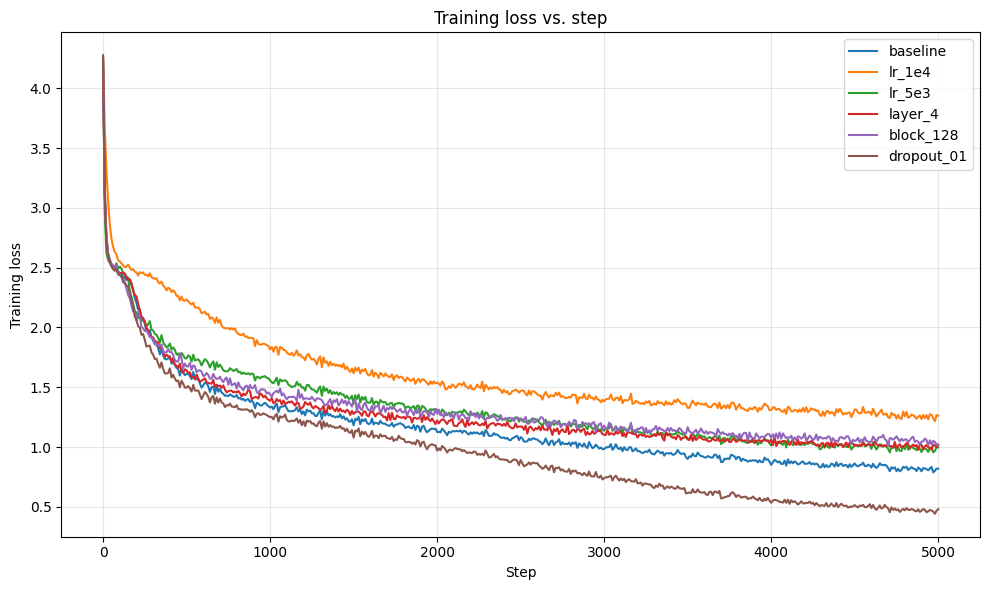

Saved: /content/nanoGPT/plots/train_loss_plot.png


In [ ]:
# Create a new figure for the training-loss comparison plot.
# figsize controls the size of the figure in inches.
plt.figure(figsize=(10, 6))

# Plot one training-loss curve per experiment.
for exp_name, curves in all_curves.items():
    # Skip experiments for which no training-loss values were parsed.
    if len(curves["train_steps"]) == 0:
        continue

    # x-axis: training steps
    # y-axis: training loss at those steps
    plt.plot(curves["train_steps"], curves["train_losses"], label=exp_name)

# Label the axes so the plot is easy to interpret.
plt.xlabel("Step")
plt.ylabel("Training loss")

# Add a descriptive title.
plt.title("Training loss vs. step")

# Show a legend so we can distinguish the experiments.
plt.legend()

# Add a light grid to make it easier to compare values visually.
plt.grid(True, alpha=0.3)

# Adjust spacing automatically so labels are not cut off.
plt.tight_layout()

# Save the figure to disk for later use in the report.
train_plot_path = PLOT_DIR / "train_loss_plot.png"
plt.savefig(train_plot_path, dpi=200)

# Display the plot directly in the notebook output.
plt.show()

# Print the save location so we know where the image file was written.
print("Saved:", train_plot_path)

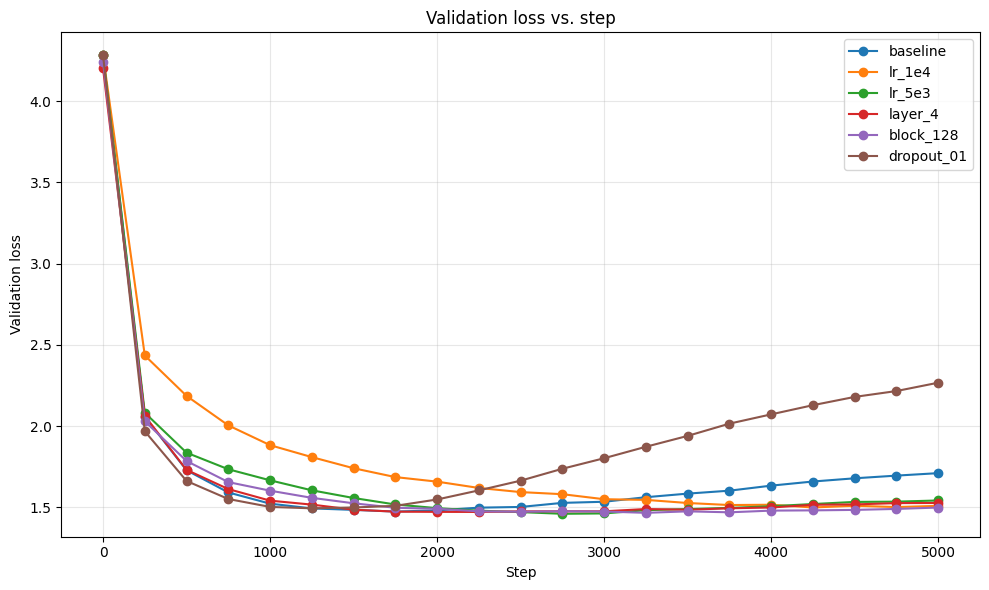

Saved: /content/nanoGPT/plots/val_loss_plot.png


In [ ]:
# do the same for valdiation loss
plt.figure(figsize=(10, 6))

for exp_name, curves in all_curves.items():
    if len(curves["eval_steps"]) == 0:
        continue
    plt.plot(curves["eval_steps"], curves["eval_val_losses"], marker="o", label=exp_name)

plt.xlabel("Step")
plt.ylabel("Validation loss")
plt.title("Validation loss vs. step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

val_plot_path = PLOT_DIR / "val_loss_plot.png"
plt.savefig(val_plot_path, dpi=200)
plt.show()

print("Saved:", val_plot_path)

## 9. Build an appendix file with all generated samples

This cell concatenates all sample outputs into one text file that can be attached as an appendix or copied into the report.


In [ ]:
# Path of the text file that will collect all generated samples in one place.
# We use this as an appendix file for the report, so all experiment outputs
# are stored together in a single document.
appendix_path = REPORT_DIR / "appendix_samples.txt"

# Open the appendix file in write mode.
# This overwrites any previous file with the same name.
with open(appendix_path, "w", encoding="utf-8") as out_file:
    # Go through all experiments in the defined order.
    for exp_name in EXPERIMENTS.keys():
        # Each experiment has its own sample text file created earlier.
        sample_path = SAMPLE_DIR / f"{exp_name}_samples.txt"

        # If the sample file does not exist, skip this experiment.
        # This prevents the notebook from crashing if sampling was not run.
        if not sample_path.exists():
            continue

        # Write a clear visual separator before each experiment section.
        out_file.write("=" * 100 + "\n")

        # Write the experiment name as a heading.
        out_file.write(f"EXPERIMENT: {exp_name}\n")

        # Write another separator line under the heading.
        out_file.write("=" * 100 + "\n\n")

        # Copy the full generated sample text into the appendix file.
        # errors="replace" ensures that reading will not fail because of any
        # unexpected character encoding issue.
        out_file.write(sample_path.read_text(encoding="utf-8", errors="replace"))

        # Add blank lines between experiments for readability.
        out_file.write("\n\n")

# Print the file path so we know where the appendix text was saved.
print("Saved:", appendix_path)

Saved: /content/nanoGPT/report_assets/appendix_samples.txt


# Bonus

In [ ]:
def plot_loss_curves_for_runs(run_to_log_path, title_prefix, file_prefix):
    """
    Plot training and validation loss curves for a selected set of runs.

    Parameters
    ----------
    run_to_log_path : dict
        Mapping from display name -> log file path
    title_prefix : str
        Prefix used in the plot titles
    file_prefix : str
        Prefix used when saving plot files
    """
    selected_curves = {}

    # Parse all available logs first
    for run_name, log_path in run_to_log_path.items():
        if not log_path.exists():
            print(f"Missing log for {run_name}: {log_path}")
            continue
        selected_curves[run_name] = parse_training_log(log_path)

    if not selected_curves:
        print("No bonus logs found, nothing to plot.")
        return

    # ---------------------------
    # Training loss plot
    # ---------------------------
    plt.figure(figsize=(10, 6))
    num_train_curves = 0

    for run_name, curves in selected_curves.items():
        if len(curves["train_steps"]) == 0 or len(curves["train_losses"]) == 0:
            print(f"Skipping training curve for {run_name}: no parsed training-loss values found.")
            continue

        plt.plot(
            curves["train_steps"],
            curves["train_losses"],
            label=run_name,
            linewidth=2,
        )
        num_train_curves += 1

    if num_train_curves == 0:
        print("No training-loss curves found for these bonus runs.")
    else:
        plt.xlabel("Step")
        plt.ylabel("Training loss")
        plt.title(f"{title_prefix}: Training loss vs. step")
        plt.grid(True, alpha=0.3)
        plt.legend(loc="best")
        plt.tight_layout()

        train_plot_path = PLOT_DIR / f"{file_prefix}_train_loss.png"
        plt.savefig(train_plot_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", train_plot_path)

    # ---------------------------
    # Validation loss plot
    # ---------------------------
    plt.figure(figsize=(10, 6))
    num_val_curves = 0

    for run_name, curves in selected_curves.items():
        if len(curves["eval_steps"]) == 0 or len(curves["eval_val_losses"]) == 0:
            print(f"Skipping validation curve for {run_name}: no parsed validation-loss values found.")
            continue

        plt.plot(
            curves["eval_steps"],
            curves["eval_val_losses"],
            marker="o",
            label=run_name,
            linewidth=2,
        )
        num_val_curves += 1

    if num_val_curves == 0:
        print("No validation-loss curves found for these bonus runs.")
    else:
        plt.xlabel("Step")
        plt.ylabel("Validation loss")
        plt.title(f"{title_prefix}: Validation loss vs. step")
        plt.grid(True, alpha=0.3)
        plt.legend(loc="best")
        plt.tight_layout()

        val_plot_path = PLOT_DIR / f"{file_prefix}_val_loss.png"
        plt.savefig(val_plot_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", val_plot_path)

## Bonus A — Custom dataset

For Bonus A, we train the same style of model on a **different dataset**.  
We use **WikiText-2**, which comfortably exceeds the assignment minimum of **500 KB** (the size is 13.3 MB). The assignment asks us to describe the dataset, preprocessing, and compare sample quality against Shakespeare.

We keep the preprocessing intentionally simple:

- load WikiText-2 with the `datasets` library,
- concatenate the text,
- save it as a plain text file,
- create a `prepare.py` file that mirrors nanoGPT's character-level data pipeline,
- train with a dedicated config and separate output directory.


In [ ]:
from datasets import load_dataset

# Name of the custom dataset directory used for Bonus A.
# We keep it separate from the Shakespeare data so the files do not mix.
BONUS_A_DATASET_NAME = "wikitext2_char_bonus"

# Full path where the Bonus A dataset files will be stored inside nanoGPT/data.
BONUS_A_DIR = REPO_DIR / "data" / BONUS_A_DATASET_NAME

# Create the directory if it does not already exist.
BONUS_A_DIR.mkdir(parents=True, exist_ok=True)

# Load the raw WikiText-2 dataset from Hugging Face.
# We use the raw version because we want plain text for character-level training.
ds = load_dataset("wikitext", "wikitext-2-raw-v1")

# Combine the train, validation, and test splits into one large text string.
# This gives us a single corpus file for Bonus A training.
#
# "\n".join(...) inserts line breaks between original text entries.
# .strip() removes leading and trailing whitespace from the final result.
all_text = "\n".join(
    list(ds["train"]["text"]) + list(ds["validation"]["text"]) + list(ds["test"]["text"])
).strip()

# Save the combined corpus as input.txt, which matches the simple text-file
# format commonly used by nanoGPT data preparation scripts.
(BONUS_A_DIR / "input.txt").write_text(all_text, encoding="utf-8")

# Compute the corpus size in megabytes so we can verify that the dataset
# is large enough for the bonus requirement.
size_mb = (BONUS_A_DIR / "input.txt").stat().st_size / (1024 * 1024)

# Print basic confirmation information.
print(f"Saved WikiText-2 raw text to {BONUS_A_DIR / 'input.txt'}")
print(f"Corpus size: {size_mb:.2f} MB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Saved WikiText-2 raw text to /content/nanoGPT/data/wikitext2_char_bonus/input.txt
Corpus size: 12.77 MB


In [ ]:
# Build the contents of the Bonus A dataset preparation script as a string.
# This script creates a character-level dataset from input.txt in the same style
# as nanoGPT's built-in Shakespeare character preparation script.
bonus_a_prepare = """
import os
import pickle
import numpy as np

# Path to the raw text file for the custom Bonus A dataset.
input_file_path = os.path.join(os.path.dirname(__file__), "input.txt")

# Read the entire corpus as one string.
with open(input_file_path, "r", encoding="utf-8") as f:
    data = f.read()

# Compute total number of characters in the corpus.
n = len(data)

# Split the text into 90% training and 10% validation characters.
train_data = data[: int(n * 0.9)]
val_data = data[int(n * 0.9):]

# Build the character vocabulary from the training split.
# Using only the training split avoids leaking validation information.
chars = sorted(list(set(train_data)))
vocab_size = len(chars)

# Create mappings:
# - stoi: string/character to integer ID
# - itos: integer ID back to character
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(text):
    # Convert each character into its integer ID.
    # Characters not seen in the training vocabulary are skipped.
    return [stoi[c] for c in text if c in stoi]

# Encode train and validation text into arrays of integer token IDs.
# uint16 is sufficient because the character vocabulary is very small.
train_ids = np.array(encode(train_data), dtype=np.uint16)
val_ids = np.array(encode(val_data), dtype=np.uint16)

# Save the encoded token IDs as binary files expected by nanoGPT.
train_ids.tofile(os.path.join(os.path.dirname(__file__), "train.bin"))
val_ids.tofile(os.path.join(os.path.dirname(__file__), "val.bin"))

# Save metadata needed later for decoding generated token IDs back into text.
meta = {
    "vocab_size": vocab_size,
    "itos": itos,
    "stoi": stoi,
}

with open(os.path.join(os.path.dirname(__file__), "meta.pkl"), "wb") as f:
    pickle.dump(meta, f)

# Print dataset statistics for a quick sanity check.
print(f"Length of dataset in characters: {n:,}")
print(f"Training characters: {len(train_ids):,}")
print(f"Validation characters: {len(val_ids):,}")
print(f"Vocabulary size: {vocab_size}")
"""

# Write the generated preparation script to disk.
(BONUS_A_DIR / "prepare.py").write_text(
    bonus_a_prepare.strip() + "\n",
    encoding="utf-8"
)

# Print the path so we can confirm where the script was saved.
print(f"Wrote {BONUS_A_DIR / 'prepare.py'}")

Wrote /content/nanoGPT/data/wikitext2_char_bonus/prepare.py


In [ ]:
# Run the custom Bonus A dataset preparation script.
# This executes prepare.py as a separate Python process, just as we would
# run it from the command line.
subprocess.run(
    [sys.executable, str(BONUS_A_DIR / "prepare.py")],
    cwd=REPO_DIR,   # run from inside the nanoGPT repository
    check=True,     # raise an error immediately if the script fails
)

# Print a confirmation message after the preparation finished successfully.
print("Bonus A dataset prepared successfully.")

Bonus A dataset prepared successfully.


In [ ]:
# Start from the baseline configuration so the Bonus A run stays as comparable
# as possible to the mandatory Shakespeare experiments.
bonus_a_config = BASE_CONFIG.copy()

# Override only the settings that should differ for Bonus A.
bonus_a_config.update({
    "out_dir": "out-wikitext2-bonus",          # separate output folder for Bonus A checkpoints/logs
    "wandb_run_name": "bonus_a_wikitext2",     # descriptive run name
    "dataset": BONUS_A_DATASET_NAME,           # use the custom WikiText-2 character dataset
})

# Path where the Bonus A nanoGPT config file will be saved.
bonus_a_config_path = CONFIG_DIR / "train_wikitext2_char_bonus.py"

# Write the configuration to disk in nanoGPT's plain Python config format.
bonus_a_config_path.write_text(
    config_to_text(bonus_a_config),
    encoding="utf-8"
)

# Print the path so we can confirm the config file was created successfully.
print(f"Wrote {bonus_a_config_path}")

Wrote /content/nanoGPT/config/train_wikitext2_char_bonus.py


In [ ]:
# Control switches for Bonus A.
# These let us decide independently whether to run training and/or sampling.
RUN_BONUS_A_TRAINING = True
RUN_BONUS_A_SAMPLING = True

# ---------------------------
# Bonus A: training
# ---------------------------
if RUN_BONUS_A_TRAINING:
    # Path where the training log for Bonus A will be stored.
    bonus_a_log = LOG_DIR / "bonus_a_wikitext2.log"

    # Only start training if the log file does not already exist.
    # This prevents accidentally retraining the model when rerunning the notebook.
    if not bonus_a_log.exists():
        # Run nanoGPT training with the Bonus A config file and record wall-clock time.
        bonus_a_time = run_and_log(
            [sys.executable, "train.py", str(bonus_a_config_path.relative_to(REPO_DIR))],
            log_path=bonus_a_log,
            cwd=REPO_DIR,
        )

        # Save the measured runtime in a small JSON file so it can be loaded later
        # for the summary table or analysis.
        (LOG_DIR / "bonus_a_wikitext2_time_minutes.json").write_text(
            json.dumps(
                {"experiment": "bonus_a_wikitext2", "time_minutes": bonus_a_time},
                indent=2
            ),
            encoding="utf-8",
        )
    else:
        # If the log already exists, assume the training run was already completed.
        print("Skipping Bonus A training because the log already exists.")

# ---------------------------
# Bonus A: sampling
# ---------------------------
if RUN_BONUS_A_SAMPLING:
    # Path where the generated samples for Bonus A will be stored.
    bonus_a_sample = SAMPLE_DIR / "bonus_a_wikitext2_samples.txt"

    # Only generate new samples if the sample file does not already exist.
    if not bonus_a_sample.exists():
        # Generate 3 text samples of 500 new tokens each from the trained Bonus A model.
        sample_experiment(
            exp_name="bonus_a_wikitext2",
            out_dir="out-wikitext2-bonus",
            num_samples=3,
            max_new_tokens=500,
        )
    else:
        # If the sample file already exists, skip regeneration.
        print("Skipping Bonus A sampling because the sample file already exists.")

Running command:
/usr/bin/python3 train.py config/train_wikitext2_char_bonus.py
--------------------------------------------------------------------------------
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_wikitext2_char_bonus.py:
# Auto-generated by the assignment notebook.
# Every setting is written explicitly for reproducibility.

out_dir = 'out-wikitext2-bonus'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'bonus_a_wikitext2'
dataset = 'wikitext2_char_bonus'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 0.001
max_iters = 5000
lr_decay_iters = 5000
min_lr = 0.0001
beta2 = 0.99


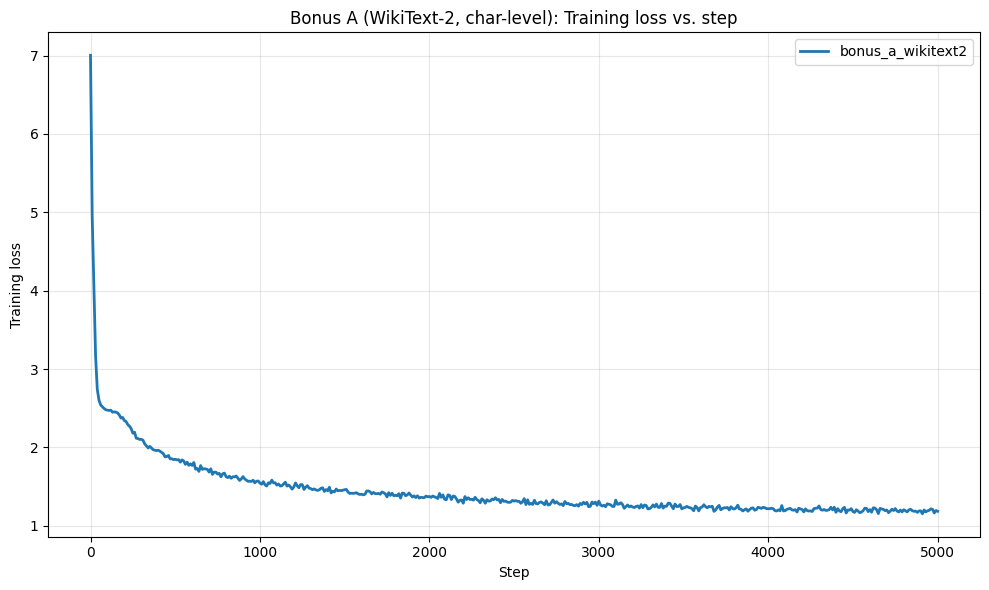

Saved: /content/nanoGPT/plots/bonus_a_wikitext2_train_loss.png


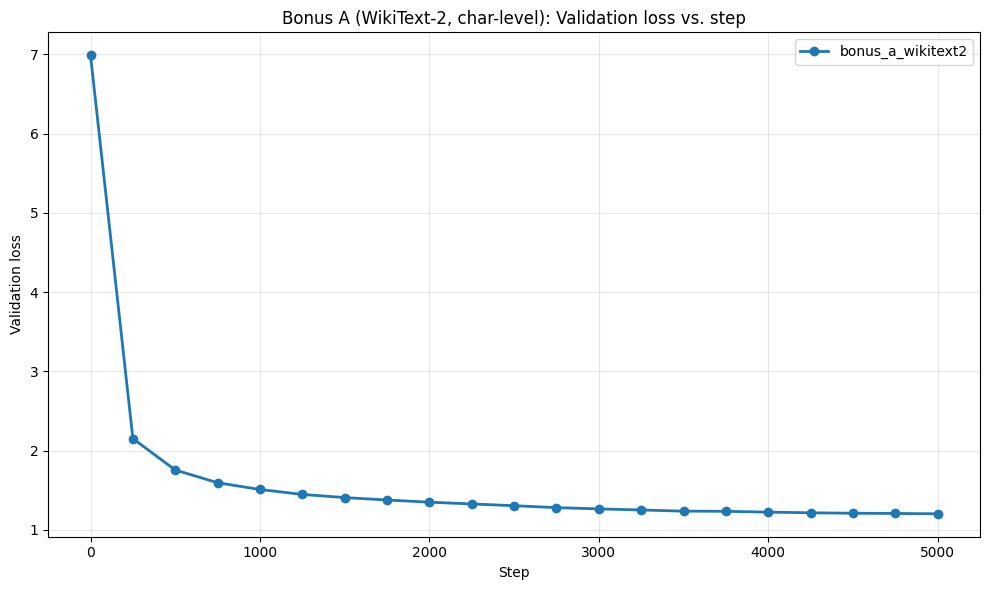

Saved: /content/nanoGPT/plots/bonus_a_wikitext2_val_loss.png


In [ ]:
bonus_a_runs = {
    "bonus_a_wikitext2": LOG_DIR / "bonus_a_wikitext2.log",
}

plot_loss_curves_for_runs(
    run_to_log_path=bonus_a_runs,
    title_prefix="Bonus A (WikiText-2, char-level)",
    file_prefix="bonus_a_wikitext2"
)

## Bonus B — Our own Byte Pair Encoding (BPE) tokenizer

For Bonus B, the assignment asks us to replace the character-level tokenizer with **our own BPE tokenizer**, train on Shakespeare, integrate it into the nanoGPT pipeline, and compare it against the character baseline.

The lecture slides describe BPE in exactly this way: start from characters, repeatedly merge the most frequent adjacent pair, and then apply the learned merges in the same order during encoding.

To keep the implementation understandable, we use a **simple whitespace-preserving BPE**:

- split the text into chunks with a regex,
- each chunk starts as a sequence of characters,
- perform a fixed number of merges on the training split,
- encode the corpus into token IDs,
- save `train.bin`, `val.bin`, and `meta.pkl` exactly where nanoGPT expects them.


In [ ]:
# --- BPE helper functions ---------------------------------------------------
# Regex pattern used to split text into chunks before BPE training.
# It keeps:
# - non-whitespace sequences together, optionally followed by trailing spaces
# - or standalone whitespace sequences
#
# This helps preserve spacing information instead of discarding spaces completely.
CHUNK_PATTERN = r"\S+\s*|\s+"

def split_into_chunks(text):
    """
    Split text into chunks that keep words/punctuation together with optional
    trailing spaces, or keep whitespace chunks by themselves.

    Example idea:
        "Hello world"
    might become:
        ["Hello ", "world"]
    """
    return re.findall(CHUNK_PATTERN, text)


In [ ]:
def get_pair_stats(word_freqs):
    """
    Count how often each adjacent symbol pair appears across the current
    tokenized vocabulary representation.

    Parameters:
    - word_freqs: dictionary mapping tuples of symbols to their frequency

    Returns:
    - Counter of adjacent symbol pairs, weighted by word frequency
    """
    pairs = Counter()

    # Go through each symbol sequence and its frequency.
    for symbols, freq in word_freqs.items():
        # Count each adjacent pair in the sequence.
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq

    return pairs


In [ ]:
def merge_pair(pair, word_freqs):
    """
    Merge one specific adjacent symbol pair everywhere it occurs.

    Example:
        pair = ("l", "o")
        ("l", "o", "w") -> ("lo", "w")

    Parameters:
    - pair: the symbol pair to merge
    - word_freqs: dictionary of symbol tuples and their frequencies

    Returns:
    - new dictionary with the chosen pair merged
    """
    merged_word_freqs = {}

    # The merged token is just the concatenation of both symbols.
    merged_symbol = "".join(pair)

    for symbols, freq in word_freqs.items():
        new_symbols = []
        i = 0

        # Walk through the symbol sequence left to right.
        while i < len(symbols):
            # If the current and next symbol match the target pair,
            # replace them with the merged symbol.
            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i + 1] == pair[1]:
                new_symbols.append(merged_symbol)
                i += 2
            else:
                # Otherwise keep the current symbol unchanged.
                new_symbols.append(symbols[i])
                i += 1

        new_symbols = tuple(new_symbols)

        # Add frequency to the new merged representation.
        merged_word_freqs[new_symbols] = merged_word_freqs.get(new_symbols, 0) + freq

    return merged_word_freqs

In [ ]:
def train_bpe(text, num_merges=200):
    """
    Train a simple BPE tokenizer on raw text.

    Steps:
    1. Split text into chunks
    2. Count chunk frequencies
    3. Represent each chunk as a tuple of characters
    4. Repeatedly merge the most frequent adjacent pair
    5. Build token-to-id and id-to-token mappings

    Parameters:
    - text: raw training text
    - num_merges: maximum number of BPE merge operations

    Returns:
    - dictionary containing merges, stoi, itos, vocab size, and pattern
    """
    # Count how often each chunk occurs.
    chunk_freqs = Counter(split_into_chunks(text))

    # Represent each chunk as a tuple of initial symbols (characters).
    word_freqs = {tuple(chunk): freq for chunk, freq in chunk_freqs.items()}

    # Initial vocabulary consists of all single characters seen in the chunks.
    vocab = set()
    for symbols in word_freqs.keys():
        vocab.update(symbols)

    merges = []

    # Iteratively learn the most frequent adjacent pair.
    for _ in range(num_merges):
        pair_stats = get_pair_stats(word_freqs)

        # Stop if no adjacent pairs remain.
        if not pair_stats:
            break

        # Take the most frequent pair.
        best_pair, best_freq = pair_stats.most_common(1)[0]

        # Stop early if the best pair occurs only once.
        # Merging such rare pairs is usually not useful.
        if best_freq < 2:
            break

        merges.append(best_pair)

        # Apply the merge to all chunks.
        word_freqs = merge_pair(best_pair, word_freqs)

        # Add the merged token to the vocabulary.
        vocab.add("".join(best_pair))

    # Sort vocabulary for stable token ordering.
    vocab = sorted(vocab)

    # Build token-id mappings.
    stoi = {token: idx for idx, token in enumerate(vocab)}
    itos = {idx: token for token, idx in stoi.items()}

    return {
        "merges": merges,
        "stoi": stoi,
        "itos": itos,
        "vocab_size": len(vocab),
        "pattern": CHUNK_PATTERN,
    }

In [ ]:
def apply_bpe_merges(symbols, merges):
    """
    Apply the learned BPE merges to one sequence of symbols.

    Parameters:
    - symbols: list of initial symbols, usually characters
    - merges: list of learned merge pairs in training order

    Returns:
    - list of merged tokens
    """
    symbols = list(symbols)

    # Apply merges in the exact order in which they were learned.
    for pair in merges:
        merged_symbol = "".join(pair)
        new_symbols = []
        i = 0

        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i + 1] == pair[1]:
                new_symbols.append(merged_symbol)
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1

        symbols = new_symbols

    return symbols


In [ ]:
def encode_bpe(text, tokenizer_meta):
    """
    Encode raw text into BPE token IDs.

    Steps:
    1. Split text into chunks
    2. Apply learned merges to each chunk
    3. Convert resulting tokens to integer IDs

    Parameters:
    - text: raw input text
    - tokenizer_meta: dictionary returned by train_bpe

    Returns:
    - list of integer token IDs
    """
    token_ids = []
    merges = tokenizer_meta["merges"]
    stoi = tokenizer_meta["stoi"]

    for chunk in split_into_chunks(text):
        tokens = apply_bpe_merges(list(chunk), merges)
        token_ids.extend(stoi[token] for token in tokens)

    return token_ids

In [ ]:
def decode_bpe(token_ids, tokenizer_meta):
    """
    Decode a list of BPE token IDs back into text.

    Parameters:
    - token_ids: list of integer token IDs
    - tokenizer_meta: dictionary returned by train_bpe

    Returns:
    - reconstructed text string
    """
    itos = tokenizer_meta["itos"]
    return "".join(itos[idx] for idx in token_ids)

In [ ]:
# Path to the original Tiny Shakespeare raw text file used by nanoGPT.
shakespeare_input_path = REPO_DIR / "data" / "shakespeare_char" / "input.txt"

# Read the full Shakespeare corpus as one text string.
raw_shakespeare = shakespeare_input_path.read_text(encoding="utf-8")

# Split the corpus into training and validation text using the same 90/10 ratio
# as in the character-level preparation script.
split_index = int(0.9 * len(raw_shakespeare))
shakespeare_train_text = raw_shakespeare[:split_index]
shakespeare_val_text = raw_shakespeare[split_index:]

# Number of BPE merge operations to learn.
# More merges usually means a larger subword vocabulary.
BPE_MERGES = 200

# Train the custom BPE tokenizer on the training split only.
# This avoids leaking validation information into the tokenizer.
bpe_meta = train_bpe(shakespeare_train_text, num_merges=BPE_MERGES)

# Print basic tokenizer statistics.
print(f"BPE vocabulary size: {bpe_meta['vocab_size']}")

# Show the first few learned merges to inspect what kinds of subword units
# the tokenizer discovered.
print("First 20 learned merges:")
for pair in bpe_meta["merges"][:20]:
    print(pair, "->", "".join(pair))

# Take a small text sample for a sanity check.
sanity_text = raw_shakespeare[:5000]

# Encode the sample text into BPE token IDs.
sanity_ids = encode_bpe(sanity_text, bpe_meta)

# Decode the token IDs back into text.
sanity_roundtrip = decode_bpe(sanity_ids, bpe_meta)

# Verify that encoding followed by decoding reconstructs the original text exactly.
# If not, something is wrong in the tokenizer implementation.
assert sanity_text == sanity_roundtrip, "BPE encode/decode sanity check failed."

print("BPE round-trip sanity check passed.")

BPE vocabulary size: 265
First 20 learned merges:
('e', ' ') -> e 
('t', 'h') -> th
('t', ' ') -> t 
('s', ' ') -> s 
('d', ' ') -> d 
(',', ' ') -> , 
('o', 'u') -> ou
('e', 'r') -> er
('i', 'n') -> in
('y', ' ') -> y 
('a', 'n') -> an
('o', 'r') -> or
(':', '\n') -> :

('o', ' ') -> o 
('e', 'n') -> en
('a', 'r') -> ar
('\n', '\n') -> 


('o', 'n') -> on
('l', 'l') -> ll
('h', 'a') -> ha
BPE round-trip sanity check passed.


In [ ]:
# Create a dataset name that includes the number of learned BPE merges.
# This makes it easy to tell different BPE tokenizers apart if we later
# experiment with other merge counts.
BPE_DATASET_NAME = f"shakespeare_bpe_{BPE_MERGES}"

# Path where the BPE-based Shakespeare dataset will be stored.
BPE_DATA_DIR = REPO_DIR / "data" / BPE_DATASET_NAME

# Create the dataset directory if it does not already exist.
BPE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save the raw Shakespeare text into the new dataset directory as input.txt.
# This mirrors the structure used by the built-in nanoGPT datasets.
(BPE_DATA_DIR / "input.txt").write_text(raw_shakespeare, encoding="utf-8")

# Encode the training and validation text with the custom BPE tokenizer.
# The result is a sequence of integer token IDs.
bpe_train_ids = np.array(encode_bpe(shakespeare_train_text, bpe_meta), dtype=np.uint16)
bpe_val_ids = np.array(encode_bpe(shakespeare_val_text, bpe_meta), dtype=np.uint16)

# Save the encoded token IDs in the binary format expected by nanoGPT.
bpe_train_ids.tofile(BPE_DATA_DIR / "train.bin")
bpe_val_ids.tofile(BPE_DATA_DIR / "val.bin")

# Create the metadata dictionary that nanoGPT (and our own analysis code)
# can later use to decode token IDs back into text and to inspect the tokenizer.
meta_for_nanogpt = {
    "vocab_size": bpe_meta["vocab_size"],  # number of BPE tokens in the vocabulary
    "stoi": bpe_meta["stoi"],              # mapping from token string to integer ID
    "itos": bpe_meta["itos"],              # mapping from integer ID back to token string
    "merges": bpe_meta["merges"],          # learned merge operations in order
    "pattern": bpe_meta["pattern"],        # regex pattern used for chunk splitting
    "seed": SEED,                          # record seed for reproducibility
}

# Save the metadata as a pickle file, following nanoGPT's usual dataset format.
with open(BPE_DATA_DIR / "meta.pkl", "wb") as f:
    pickle.dump(meta_for_nanogpt, f)

# Print a small summary so we can verify that dataset creation worked.
print(f"Saved BPE dataset to: {BPE_DATA_DIR}")
print(f"Train tokens: {len(bpe_train_ids):,}")
print(f"Val tokens  : {len(bpe_val_ids):,}")

Saved BPE dataset to: /content/nanoGPT/data/shakespeare_bpe_200
Train tokens: 526,244
Val tokens  : 58,683


In [ ]:
# Build the contents of the Bonus B preparation script as a string.
# This script will:
# 1. read raw Shakespeare text from input.txt
# 2. train a simple custom BPE tokenizer on the training split
# 3. encode the train and validation text into token IDs
# 4. save train.bin, val.bin, and meta.pkl in nanoGPT format
bonus_b_prepare = '\nimport os\nimport re\nimport pickle\nimport numpy as np\nfrom collections import Counter\n\n# Regex pattern used to split text into chunks before BPE training.\n# It keeps non-whitespace text together and preserves whitespace chunks.\nCHUNK_PATTERN = r"\\\\S+\\\\s*|\\\\s+"\n\n# Number of BPE merge operations to learn.\nNUM_MERGES = 200\n\ndef split_into_chunks(text):\n    # Split raw text into chunks for BPE training and encoding.\n    return re.findall(CHUNK_PATTERN, text)\n\ndef get_pair_stats(word_freqs):\n    # Count how often each adjacent symbol pair occurs.\n    pairs = Counter()\n    for symbols, freq in word_freqs.items():\n        for a, b in zip(symbols, symbols[1:]):\n            pairs[(a, b)] += freq\n    return pairs\n\ndef merge_pair(pair, word_freqs):\n    # Merge one chosen adjacent pair everywhere it appears.\n    merged_word_freqs = {}\n    merged_symbol = "".join(pair)\n    for symbols, freq in word_freqs.items():\n        new_symbols = []\n        i = 0\n        while i < len(symbols):\n            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i + 1] == pair[1]:\n                new_symbols.append(merged_symbol)\n                i += 2\n            else:\n                new_symbols.append(symbols[i])\n                i += 1\n        new_symbols = tuple(new_symbols)\n        merged_word_freqs[new_symbols] = merged_word_freqs.get(new_symbols, 0) + freq\n    return merged_word_freqs\n\ndef train_bpe(text, num_merges=NUM_MERGES):\n    # Count chunk frequencies and represent each chunk as a tuple of characters.\n    chunk_freqs = Counter(split_into_chunks(text))\n    word_freqs = {tuple(chunk): freq for chunk, freq in chunk_freqs.items()}\n\n    # Initial vocabulary consists of all single characters.\n    vocab = set()\n    for symbols in word_freqs:\n        vocab.update(symbols)\n\n    merges = []\n    for _ in range(num_merges):\n        # Find the most frequent adjacent pair.\n        pair_stats = get_pair_stats(word_freqs)\n        if not pair_stats:\n            break\n        best_pair, best_freq = pair_stats.most_common(1)[0]\n\n        # Stop if no useful merge remains.\n        if best_freq < 2:\n            break\n\n        # Record the merge and apply it to the whole training representation.\n        merges.append(best_pair)\n        word_freqs = merge_pair(best_pair, word_freqs)\n        vocab.add("".join(best_pair))\n\n    # Build token-id mappings.\n    vocab = sorted(vocab)\n    stoi = {token: idx for idx, token in enumerate(vocab)}\n    itos = {idx: token for token, idx in stoi.items()}\n\n    return {\n        "merges": merges,\n        "stoi": stoi,\n        "itos": itos,\n        "vocab_size": len(vocab),\n        "pattern": CHUNK_PATTERN,\n    }\n\ndef apply_bpe_merges(symbols, merges):\n    # Apply learned merges in training order to one symbol sequence.\n    symbols = list(symbols)\n    for pair in merges:\n        merged_symbol = "".join(pair)\n        new_symbols = []\n        i = 0\n        while i < len(symbols):\n            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i + 1] == pair[1]:\n                new_symbols.append(merged_symbol)\n                i += 2\n            else:\n                new_symbols.append(symbols[i])\n                i += 1\n        symbols = new_symbols\n    return symbols\n\ndef encode_bpe(text, tokenizer_meta):\n    # Encode raw text into a sequence of BPE token IDs.\n    token_ids = []\n    merges = tokenizer_meta["merges"]\n    stoi = tokenizer_meta["stoi"]\n    for chunk in split_into_chunks(text):\n        tokens = apply_bpe_merges(list(chunk), merges)\n        token_ids.extend(stoi[token] for token in tokens)\n    return token_ids\n\n# Resolve dataset paths.\ndataset_dir = os.path.dirname(__file__)\ninput_file = os.path.join(dataset_dir, "input.txt")\n\n# Read the raw input text.\nwith open(input_file, "r", encoding="utf-8") as f:\n    data = f.read()\n\n# Split the corpus into 90% train and 10% validation text.\nsplit_index = int(0.9 * len(data))\ntrain_text = data[:split_index]\nval_text = data[split_index:]\n\n# Train the BPE tokenizer only on the training split.\ntokenizer_meta = train_bpe(train_text, NUM_MERGES)\n\n# Encode the train and validation text with the learned tokenizer.\ntrain_ids = np.array(encode_bpe(train_text, tokenizer_meta), dtype=np.uint16)\nval_ids = np.array(encode_bpe(val_text, tokenizer_meta), dtype=np.uint16)\n\n# Save encoded token IDs in nanoGPT binary format.\ntrain_ids.tofile(os.path.join(dataset_dir, "train.bin"))\nval_ids.tofile(os.path.join(dataset_dir, "val.bin"))\n\n# Save tokenizer metadata needed for decoding and later inspection.\nmeta = {\n    "vocab_size": tokenizer_meta["vocab_size"],\n    "stoi": tokenizer_meta["stoi"],\n    "itos": tokenizer_meta["itos"],\n    "merges": tokenizer_meta["merges"],\n    "pattern": tokenizer_meta["pattern"],\n}\n\nwith open(os.path.join(dataset_dir, "meta.pkl"), "wb") as f:\n    pickle.dump(meta, f)\n\n# Print a short summary for a sanity check.\nprint(f"BPE vocabulary size: {tokenizer_meta[\\\'vocab_size\\\']}")\nprint(f"Train tokens: {len(train_ids):,}")\nprint(f"Val tokens: {len(val_ids):,}")\n'

# Write the generated Bonus B preparation script to disk.
# .strip() removes the leading newline from the multi-line string.
# + "\\n" ensures the saved file ends with a clean final newline.
(BPE_DATA_DIR / "prepare.py").write_text(bonus_b_prepare.strip() + "\n", encoding="utf-8")

# Print the output path so we can confirm the script was created.
print(f"Wrote {BPE_DATA_DIR / 'prepare.py'}")

Wrote /content/nanoGPT/data/shakespeare_bpe_200/prepare.py


In [ ]:
# Start from the baseline configuration so the Bonus B experiment remains
# directly comparable to the character-level baseline.
bonus_b_config = BASE_CONFIG.copy()

# Override only the settings that must change for the BPE-based experiment.
bonus_b_config.update({
    "out_dir": f"out-{BPE_DATASET_NAME}",              # separate output folder for BPE checkpoints/logs
    "wandb_run_name": f"bonus_b_{BPE_DATASET_NAME}",  # descriptive run name for this bonus experiment
    "dataset": BPE_DATASET_NAME,                      # use the custom BPE-prepared Shakespeare dataset
})

# Path where the nanoGPT config file for Bonus B will be saved.
bonus_b_config_path = CONFIG_DIR / f"train_{BPE_DATASET_NAME}.py"

# Write the configuration to disk in nanoGPT's plain Python config format.
bonus_b_config_path.write_text(
    config_to_text(bonus_b_config),
    encoding="utf-8"
)

# Print the path so we can confirm that the config file was created.
print(f"Wrote {bonus_b_config_path}")

Wrote /content/nanoGPT/config/train_shakespeare_bpe_200.py


In [ ]:
# Control switches for Bonus B.
# These flags let us decide independently whether to run training and/or
# sampling for the BPE-based experiment.
RUN_BONUS_B_TRAINING = True
RUN_BONUS_B_SAMPLING = True

# ---------------------------
# Bonus B: training
# ---------------------------
if RUN_BONUS_B_TRAINING:
    # Path where the training log for the Bonus B experiment will be stored.
    bonus_b_log = LOG_DIR / f"bonus_b_{BPE_DATASET_NAME}.log"

    # Only start training if the log file does not already exist.
    # This avoids accidentally repeating a completed training run.
    if not bonus_b_log.exists():
        # Run nanoGPT training with the Bonus B config file and measure
        # the wall-clock time.
        bonus_b_time = run_and_log(
            [sys.executable, "train.py", str(bonus_b_config_path.relative_to(REPO_DIR))],
            log_path=bonus_b_log,
            cwd=REPO_DIR,
        )

        # Save the measured runtime in a small JSON file so it can be loaded
        # later for the summary table or final analysis.
        (LOG_DIR / f"bonus_b_{BPE_DATASET_NAME}_time_minutes.json").write_text(
            json.dumps(
                {
                    "experiment": f"bonus_b_{BPE_DATASET_NAME}",
                    "time_minutes": bonus_b_time
                },
                indent=2
            ),
            encoding="utf-8",
        )
    else:
        # If the log already exists, assume the training run was already completed.
        print("Skipping Bonus B training because the log already exists.")

# ---------------------------
# Bonus B: sampling
# ---------------------------
if RUN_BONUS_B_SAMPLING:
    # Path where the generated text samples for Bonus B will be stored.
    bonus_b_sample = SAMPLE_DIR / f"bonus_b_{BPE_DATASET_NAME}_samples.txt"

    # Only generate new samples if the sample file does not already exist.
    if not bonus_b_sample.exists():
        # Generate 3 samples with 500 new tokens each from the trained
        # BPE-based Shakespeare model.
        sample_experiment(
            exp_name=f"bonus_b_{BPE_DATASET_NAME}",
            out_dir=f"out-{BPE_DATASET_NAME}",
            num_samples=3,
            max_new_tokens=500,
        )
    else:
        # If the sample file already exists, skip regeneration.
        print("Skipping Bonus B sampling because the sample file already exists.")

Running command:
/usr/bin/python3 train.py config/train_shakespeare_bpe_200.py
--------------------------------------------------------------------------------
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_bpe_200.py:
# Auto-generated by the assignment notebook.
# Every setting is written explicitly for reproducibility.

out_dir = 'out-shakespeare_bpe_200'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'bonus_b_shakespeare_bpe_200'
dataset = 'shakespeare_bpe_200'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 0.001
max_iters = 5000
lr_decay_iters = 5000
min_lr = 0.0001
be

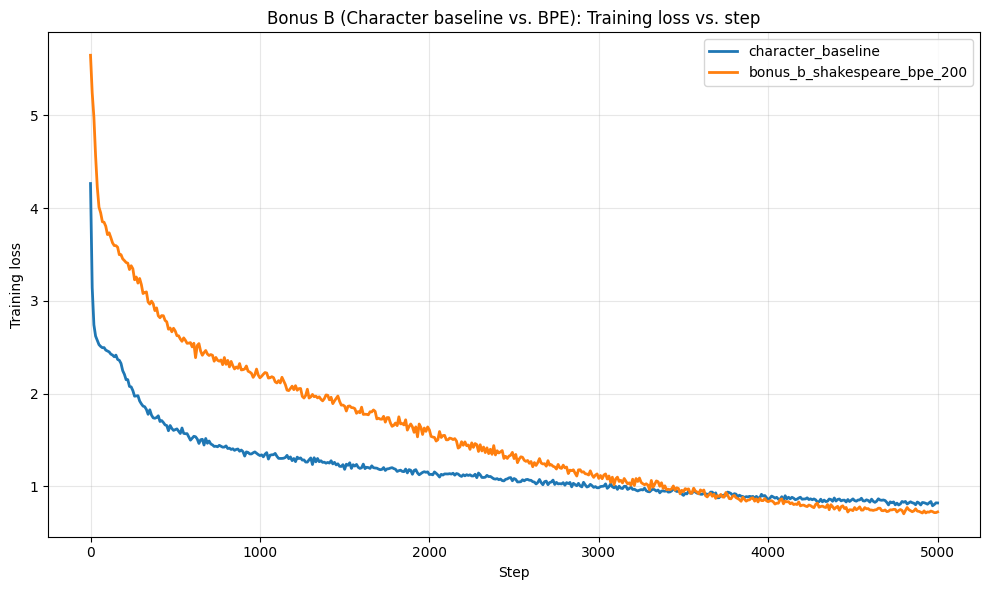

Saved: /content/nanoGPT/plots/bonus_b_comparison_train_loss.png


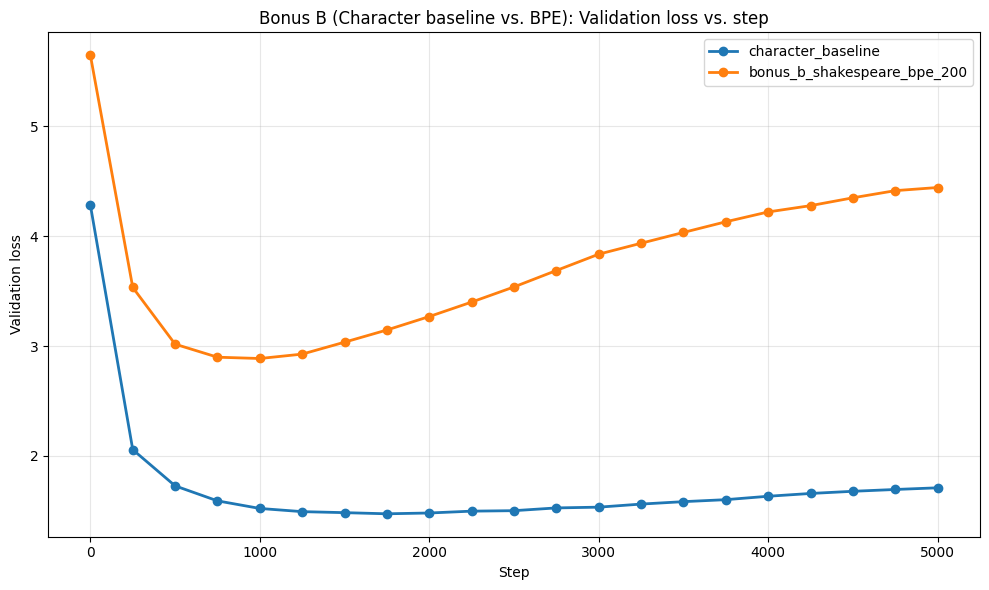

Saved: /content/nanoGPT/plots/bonus_b_comparison_val_loss.png


In [ ]:
bonus_b_runs = {
    "character_baseline": LOG_DIR / "baseline.log",
    f"bonus_b_{BPE_DATASET_NAME}": LOG_DIR / f"bonus_b_{BPE_DATASET_NAME}.log",
}

plot_loss_curves_for_runs(
    run_to_log_path=bonus_b_runs,
    title_prefix="Bonus B (Character baseline vs. BPE)",
    file_prefix="bonus_b_comparison"
)

### Bonus B comparison helper

The next cell compares the **character baseline** and the **BPE run** side by side once both logs are available.


In [ ]:
# List that will collect one comparison row per run.
# Here we want to compare the original character-level baseline against
# the Bonus B BPE-based version.
bonus_compare_rows = []

# ---------------------------
# Baseline character model
# ---------------------------

baseline_log = LOG_DIR / "baseline.log"

if baseline_log.exists():
    baseline_curves = parse_training_log(baseline_log)

    baseline_train_loss = (
        baseline_curves["eval_train_losses"][-1]
        if baseline_curves["eval_train_losses"] else np.nan
    )
    baseline_val_loss = (
        baseline_curves["eval_val_losses"][-1]
        if baseline_curves["eval_val_losses"] else np.nan
    )

    bonus_compare_rows.append({
        "Run": "character_baseline",
        "Train Loss": baseline_train_loss,
        "Val Loss": baseline_val_loss,
        "Train Perplexity": loss_to_perplexity(baseline_train_loss),
        "Val Perplexity": loss_to_perplexity(baseline_val_loss),
        "Time (min)": load_elapsed_minutes("baseline"),
    })

# ---------------------------
# Bonus B: BPE model
# ---------------------------

bonus_b_log = LOG_DIR / f"bonus_b_{BPE_DATASET_NAME}.log"
bonus_b_time_file = LOG_DIR / f"bonus_b_{BPE_DATASET_NAME}_time_minutes.json"

if bonus_b_log.exists():
    bpe_curves = parse_training_log(bonus_b_log)

    bpe_train_loss = (
        bpe_curves["eval_train_losses"][-1]
        if bpe_curves["eval_train_losses"] else np.nan
    )
    bpe_val_loss = (
        bpe_curves["eval_val_losses"][-1]
        if bpe_curves["eval_val_losses"] else np.nan
    )

    bonus_compare_rows.append({
        "Run": f"bpe_{BPE_DATASET_NAME}",
        "Train Loss": bpe_train_loss,
        "Val Loss": bpe_val_loss,
        "Train Perplexity": loss_to_perplexity(bpe_train_loss),
        "Val Perplexity": loss_to_perplexity(bpe_val_loss),
        "Time (min)": json.loads(bonus_b_time_file.read_text(encoding="utf-8"))["time_minutes"]
        if bonus_b_time_file.exists() else np.nan,
    })

bonus_compare_df = pd.DataFrame(bonus_compare_rows)
bonus_compare_df.to_csv(REPORT_DIR / "bonus_b_comparison.csv", index=False)

print("Saved:", REPORT_DIR / "bonus_b_comparison.csv")
bonus_compare_df

Saved: /content/nanoGPT/report_assets/bonus_b_comparison.csv


,Run,Train Loss,Val Loss,Train Perplexity,Val Perplexity,Time (min)
0,character_baseline,0.6200,1.7103,1.858928,5.530620,7.922771
1,bpe_shakespeare_bpe_200,0.2204,4.4430,1.246575,85.029648,7.876097


### Train a separate BPE tokenizer on the Bonus A custom dataset

In [ ]:
# Bonus B on the custom Bonus A corpus:
# train a separate BPE tokenizer on the raw text used in Bonus A.

# Path to the raw custom corpus from Bonus A.
custom_input_path = BONUS_A_DIR / "input.txt"

# Read the full custom corpus as one text string.
raw_custom_text = custom_input_path.read_text(encoding="utf-8")

# Use the same 90/10 split as Bonus A so the comparison stays fair.
custom_split_index = int(0.9 * len(raw_custom_text))
custom_train_text = raw_custom_text[:custom_split_index]
custom_val_text = raw_custom_text[custom_split_index:]

# Number of BPE merge operations for the custom dataset tokenizer.
CUSTOM_BPE_MERGES = 200

# Train the BPE tokenizer on the training split only.
custom_bpe_meta = train_bpe(custom_train_text, num_merges=CUSTOM_BPE_MERGES)

print(f"Custom BPE vocabulary size: {custom_bpe_meta['vocab_size']}")
print("First 20 learned merges on the custom dataset:")
for pair in custom_bpe_meta["merges"][:20]:
    print(pair, "->", "".join(pair))

# Quick round-trip sanity check.
custom_sanity_text = raw_custom_text[:5000]
custom_sanity_ids = encode_bpe(custom_sanity_text, custom_bpe_meta)
custom_sanity_roundtrip = decode_bpe(custom_sanity_ids, custom_bpe_meta)
assert custom_sanity_text == custom_sanity_roundtrip, "Custom BPE encode/decode sanity check failed."

print("Custom-dataset BPE round-trip sanity check passed.")

Custom BPE vocabulary size: 1318
First 20 learned merges on the custom dataset:
('e', ' ') -> e 
('s', ' ') -> s 
('t', 'h') -> th
('d', ' ') -> d 
('n', ' ') -> n 
('e', 'r') -> er
('t', ' ') -> t 
('th', 'e ') -> the 
('i', 'n') -> in
('a', 'n') -> an
(',', ' ') -> , 
('y', ' ') -> y 
('e', 'd ') -> ed 
('o', 'r') -> or
('.', ' ') -> . 
('a', 'r') -> ar
('a', 'l') -> al
('o', ' ') -> o 
('f', ' ') -> f 
('r', 'e') -> re
Custom-dataset BPE round-trip sanity check passed.


#### Build the nanoGPT dataset files for the custom BPE dataset

In [ ]:
# Create a new dataset name so we do not overwrite the existing Bonus A
# character-level dataset or the Shakespeare BPE dataset.
CUSTOM_BPE_DATASET_NAME = f"{BONUS_A_DATASET_NAME.replace('_char_bonus', '')}_bpe_bonus_{CUSTOM_BPE_MERGES}"

CUSTOM_BPE_DATA_DIR = REPO_DIR / "data" / CUSTOM_BPE_DATASET_NAME
CUSTOM_BPE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save the raw text for completeness.
(CUSTOM_BPE_DATA_DIR / "input.txt").write_text(raw_custom_text, encoding="utf-8")

# Remove characters from validation that never appeared in the training split.
train_char_set = set(custom_train_text)
removed_from_val = sorted(set(ch for ch in custom_val_text if ch not in train_char_set))

filtered_custom_val_text = "".join(ch for ch in custom_val_text if ch in train_char_set)

print(f"Removed {len(custom_val_text) - len(filtered_custom_val_text)} validation characters unseen in training.")
print(f"Unique removed characters: {removed_from_val[:50]}")
if len(removed_from_val) > 50:
    print(f"... and {len(removed_from_val) - 50} more")

# Encode train/validation splits with the custom BPE tokenizer.
custom_bpe_train_ids = np.array(encode_bpe(custom_train_text, custom_bpe_meta), dtype=np.uint16)
custom_bpe_val_ids = np.array(encode_bpe(filtered_custom_val_text, custom_bpe_meta), dtype=np.uint16)

# Save the binary token files expected by nanoGPT.
custom_bpe_train_ids.tofile(CUSTOM_BPE_DATA_DIR / "train.bin")
custom_bpe_val_ids.tofile(CUSTOM_BPE_DATA_DIR / "val.bin")

# Save the filtered validation text too, so it is clear what was actually used.
(CUSTOM_BPE_DATA_DIR / "val_filtered_for_bpe.txt").write_text(filtered_custom_val_text, encoding="utf-8")

# Save metadata in the same format our notebook already uses.
custom_meta_for_nanogpt = {
    "vocab_size": custom_bpe_meta["vocab_size"],
    "stoi": custom_bpe_meta["stoi"],
    "itos": custom_bpe_meta["itos"],
    "merges": custom_bpe_meta["merges"],
    "pattern": custom_bpe_meta["pattern"],
    "seed": SEED,
}

with open(CUSTOM_BPE_DATA_DIR / "meta.pkl", "wb") as f:
    pickle.dump(custom_meta_for_nanogpt, f)

print(f"Saved custom BPE dataset to: {CUSTOM_BPE_DATA_DIR}")
print(f"Train tokens: {len(custom_bpe_train_ids):,}")
print(f"Val tokens  : {len(custom_bpe_val_ids):,}")

Removed 54 validation characters unseen in training.
Unique removed characters: ['©', 'ǐ', 'ǜ', '͘', 'ڠ', 'ष', 'ो', 'ẩ', '₩', '₱', '为', '伊', '八', '利', '勢', '型', '士', '学', '开', '律', '成', '智', '東', '民', '甫', '甲', '秘', '聖', '艦', '處', '衛', '贈', '邵', '鉄', '魯']
Saved custom BPE dataset to: /content/nanoGPT/data/wikitext2_bpe_bonus_200
Train tokens: 6,089,233
Val tokens  : 679,359


#### Create a config for the custom-dataset BPE run
This starts from bonus_a_config, so the comparison against Bonus A is controlled: same model/training settings, different tokenizer only.

In [ ]:
# Start from the Bonus A config so the comparison is as fair as possible.
# This means we keep the same custom corpus and the same hyperparameters,
# and change only the tokenization.
custom_bonus_b_config = bonus_a_config.copy()

custom_bonus_b_config.update({
    "out_dir": f"out-{CUSTOM_BPE_DATASET_NAME}",
    "wandb_run_name": f"bonus_b_{CUSTOM_BPE_DATASET_NAME}",
    "dataset": CUSTOM_BPE_DATASET_NAME,
})

custom_bonus_b_config_path = CONFIG_DIR / f"train_{CUSTOM_BPE_DATASET_NAME}.py"

custom_bonus_b_config_path.write_text(
    config_to_text(custom_bonus_b_config),
    encoding="utf-8"
)

print(f"Wrote {custom_bonus_b_config_path}")

Wrote /content/nanoGPT/config/train_wikitext2_bpe_bonus_200.py


#### Train and sample the custom-dataset BPE model

In [ ]:
RUN_CUSTOM_BONUS_B_TRAINING = True
RUN_CUSTOM_BONUS_B_SAMPLING = True

# ---------------------------
# Bonus B on custom dataset: training
# ---------------------------
if RUN_CUSTOM_BONUS_B_TRAINING:
    custom_bonus_b_log = LOG_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}.log"

    if not custom_bonus_b_log.exists():
        custom_bonus_b_time = run_and_log(
            [sys.executable, "train.py", str(custom_bonus_b_config_path.relative_to(REPO_DIR))],
            log_path=custom_bonus_b_log,
            cwd=REPO_DIR,
        )

        (LOG_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}_time_minutes.json").write_text(
            json.dumps(
                {
                    "experiment": f"bonus_b_{CUSTOM_BPE_DATASET_NAME}",
                    "time_minutes": custom_bonus_b_time,
                },
                indent=2,
            ),
            encoding="utf-8",
        )
    else:
        print("Skipping custom Bonus B training because the log already exists.")

# ---------------------------
# Bonus B on custom dataset: sampling
# ---------------------------
if RUN_CUSTOM_BONUS_B_SAMPLING:
    custom_bonus_b_sample = SAMPLE_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}_samples.txt"

    if not custom_bonus_b_sample.exists():
        sample_experiment(
            exp_name=f"bonus_b_{CUSTOM_BPE_DATASET_NAME}",
            out_dir=f"out-{CUSTOM_BPE_DATASET_NAME}",
            num_samples=3,
            max_new_tokens=500,
        )
    else:
        print("Skipping custom Bonus B sampling because the sample file already exists.")

Running command:
/usr/bin/python3 train.py config/train_wikitext2_bpe_bonus_200.py
--------------------------------------------------------------------------------
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_wikitext2_bpe_bonus_200.py:
# Auto-generated by the assignment notebook.
# Every setting is written explicitly for reproducibility.

out_dir = 'out-wikitext2_bpe_bonus_200'
eval_interval = 250
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'bonus_b_wikitext2_bpe_bonus_200'
dataset = 'wikitext2_bpe_bonus_200'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 0.001
max_iters = 5000
lr_decay_iters = 500

#### Compare it directly with Bonus A
This compares:

Bonus A = custom dataset, character-level

Bonus B (custom) = same custom dataset, BPE tokenization

In [ ]:
# Compare Bonus A (character-level custom dataset) vs
# Bonus B on the same custom dataset with BPE tokenization.

bonus_a_vs_custom_bpe_rows = []

# ---------------------------
# Bonus A: custom char-level run
# ---------------------------
bonus_a_log = LOG_DIR / "bonus_a_wikitext2.log"

if bonus_a_log.exists():
    bonus_a_curves = parse_training_log(bonus_a_log)

    bonus_a_vs_custom_bpe_rows.append({
        "Run": "bonus_a_custom_char",
        "Train Loss": bonus_a_curves["eval_train_losses"][-1]
        if bonus_a_curves["eval_train_losses"] else np.nan,
        "Val Loss": bonus_a_curves["eval_val_losses"][-1]
        if bonus_a_curves["eval_val_losses"] else np.nan,
        "Time (min)": load_elapsed_minutes("bonus_a_wikitext2"),
    })

# ---------------------------
# Bonus B: same custom dataset, but BPE
# ---------------------------
custom_bonus_b_log = LOG_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}.log"
custom_bonus_b_time_file = LOG_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}_time_minutes.json"

if custom_bonus_b_log.exists():
    custom_bpe_curves = parse_training_log(custom_bonus_b_log)

    bonus_a_vs_custom_bpe_rows.append({
        "Run": f"bonus_b_custom_bpe_{CUSTOM_BPE_DATASET_NAME}",
        "Train Loss": custom_bpe_curves["eval_train_losses"][-1]
        if custom_bpe_curves["eval_train_losses"] else np.nan,
        "Val Loss": custom_bpe_curves["eval_val_losses"][-1]
        if custom_bpe_curves["eval_val_losses"] else np.nan,
        "Time (min)": json.loads(custom_bonus_b_time_file.read_text(encoding="utf-8"))["time_minutes"]
        if custom_bonus_b_time_file.exists() else np.nan,
    })

bonus_a_vs_custom_bpe_df = pd.DataFrame(bonus_a_vs_custom_bpe_rows)
bonus_a_vs_custom_bpe_df.to_csv(
    REPORT_DIR / "bonus_a_vs_custom_bpe_comparison.csv",
    index=False
)

print("Saved:", REPORT_DIR / "bonus_a_vs_custom_bpe_comparison.csv")
bonus_a_vs_custom_bpe_df

Saved: /content/nanoGPT/report_assets/bonus_a_vs_custom_bpe_comparison.csv


,Run,Train Loss,Val Loss,Time (min)
0,bonus_a_custom_char,1.1242,1.2016,8.051263
1,bonus_b_custom_bpe_wikitext2_bpe_bonus_200,1.9236,2.1656,8.076443


### Plot the two runs together

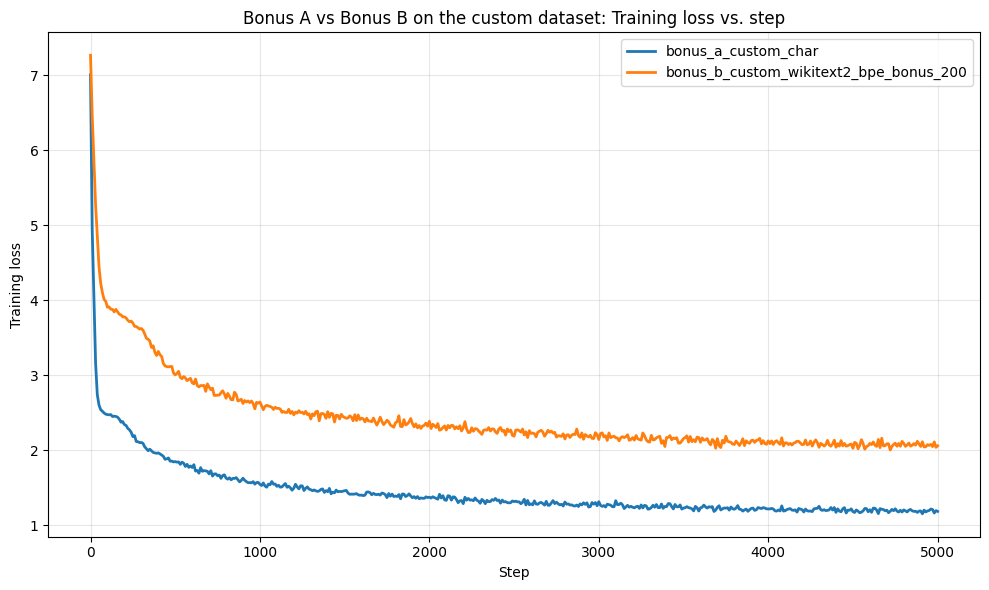

Saved: /content/nanoGPT/plots/bonus_a_vs_custom_bpe_train_loss.png


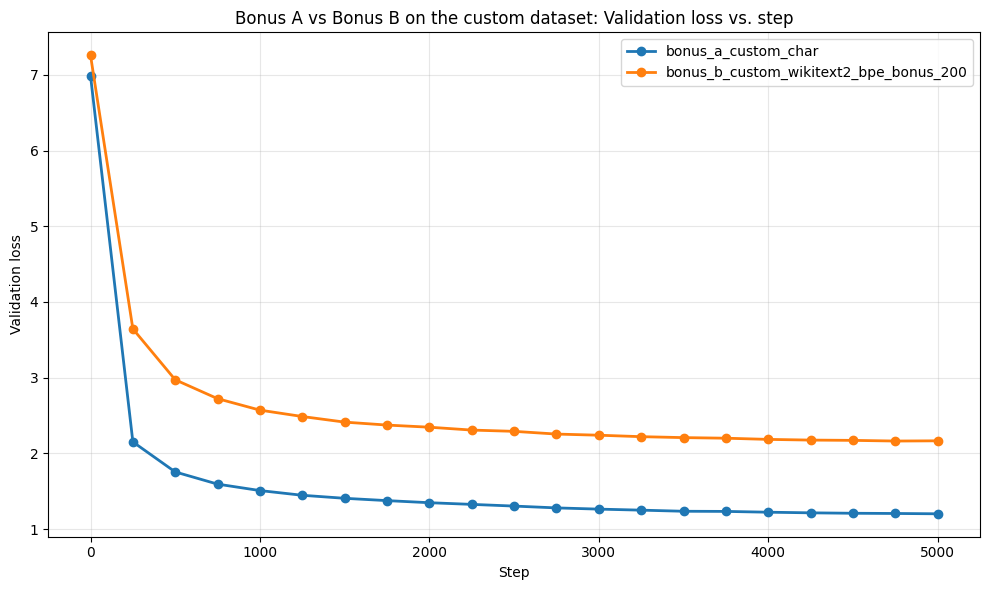

Saved: /content/nanoGPT/plots/bonus_a_vs_custom_bpe_val_loss.png


In [ ]:
bonus_a_vs_custom_bpe_runs = {
    "bonus_a_custom_char": LOG_DIR / "bonus_a_wikitext2.log",
    f"bonus_b_custom_{CUSTOM_BPE_DATASET_NAME}": LOG_DIR / f"bonus_b_{CUSTOM_BPE_DATASET_NAME}.log",
}

plot_loss_curves_for_runs(
    run_to_log_path=bonus_a_vs_custom_bpe_runs,
    title_prefix="Bonus A vs Bonus B on the custom dataset",
    file_prefix="bonus_a_vs_custom_bpe"
)

# Google Drive backup

In [ ]:
 # Uncomment this section if we want to back everything up to Google Drive.

from google.colab import drive
drive.mount("/content/drive")

DRIVE_TARGET = Path("/content/drive/MyDrive/foundations_of_nlp")
DRIVE_TARGET.mkdir(parents=True, exist_ok=True)

for folder in [LOG_DIR, PLOT_DIR, SAMPLE_DIR, REPORT_DIR]:
     target = DRIVE_TARGET / folder.name
     if target.exists():
         shutil.rmtree(target)
     shutil.copytree(folder, target)

print(f"Copied artifacts to: {DRIVE_TARGET}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied artifacts to: /content/drive/MyDrive/foundations_of_nlp
